In [ ]:
import urllib.request
import zipfile

url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
urllib.request.urlretrieve(url, "online_retail_ii.zip")

with zipfile.ZipFile("online_retail_ii.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

In [ ]:
import pandas as pd

df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')

Analyzing the dataset

In [ ]:
df.head(10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [ ]:
df.shape

(525461, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


I used .isnull() and .sum() to find the total number of null values in each column; this is important because null values in a column such as 'Customer ID' could disallow me from analyzing the 'Customer ID'column.

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


Here I drop all null values for 'Description' & 'Customer ID' so we have a clean dataset to work with.

In [ ]:
df_clean = df.dropna(subset=['Customer ID', 'Description'])

In [ ]:
df_clean.shape

(417534, 8)

In [ ]:
df_clean[df_clean['Quantity']>0].shape

(407695, 8)

I drop all rows with a quantity less than 0 because those orders are invalid, and would mess up values such as revenue.

In [ ]:
df_clean = df_clean[df_clean['Quantity']>0]

In [ ]:
df_clean.shape

(407695, 8)

I create a revenue column to track the revenue of orders.

In [ ]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

In [ ]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [ ]:
df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Customer ID,
18102.0,349164.35
14646.0,248396.50
14156.0,196566.74
14911.0,152147.57
13694.0,131443.19
...,...
15913.0,6.30
13788.0,3.75
14095.0,2.95


In [ ]:
import matplotlib.pyplot as plt

I group by customer ID to sort by total revenue in descending order to plot the top 10 customers in terms of revenue.

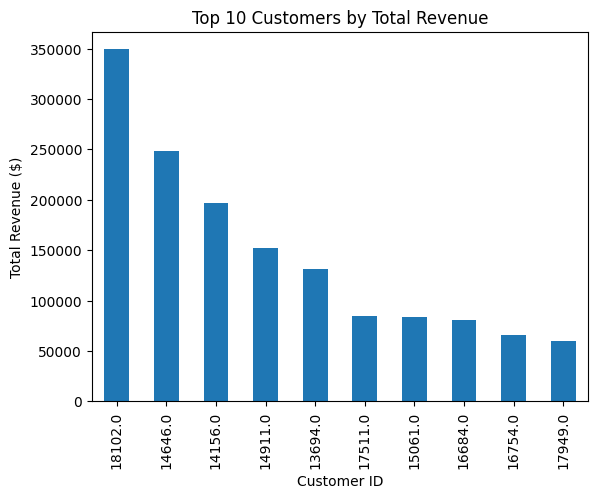

In [ ]:
df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Customers by Total Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue ($)')
plt.show()

I find the cumulative sum of the top customers to see how significant a small percentage of the customers impacts the revenue.

In [ ]:
customer_revenue = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
cum_sum_df = customer_revenue.reset_index()
cum_sum_df['Cumulative_Revenue'] = cum_sum_df['Revenue'].cumsum()
cum_sum_df.head(10)

,Customer ID,Revenue,Cumulative_Revenue
0,18102.0,349164.35,349164.35
1,14646.0,248396.50,597560.85
2,14156.0,196566.74,794127.59
3,14911.0,152147.57,946275.16
4,13694.0,131443.19,1077718.35
5,17511.0,84541.17,1162259.52
6,15061.0,83284.38,1245543.90
7,16684.0,80489.21,1326033.11
8,16754.0,65500.07,1391533.18
9,17949.0,60117.60,1451650.78
